=== DATASET LOADED ===
Records: 1000 | Variables: 12
Columns: ['Run_ID', 'Avg_temp', 'Avg_pH', 'Min_DO %', 'Inoculum size (mL)', 'Max_RPM', 'Total feed of Lactose (mL)', 'Total culture duration (days)', 'Contamination (Y/N)', 'Total media volume (mL)', 'Max FPU/ml', 'Notes']

=== DATA SOURCE ===
data_source
Synthetic    980
Real          20
Name: count, dtype: int64

=== CLEANING RESULTS ===
Original records:  1000
Records removed:   293
Clean records:     707
Real runs retained: 19


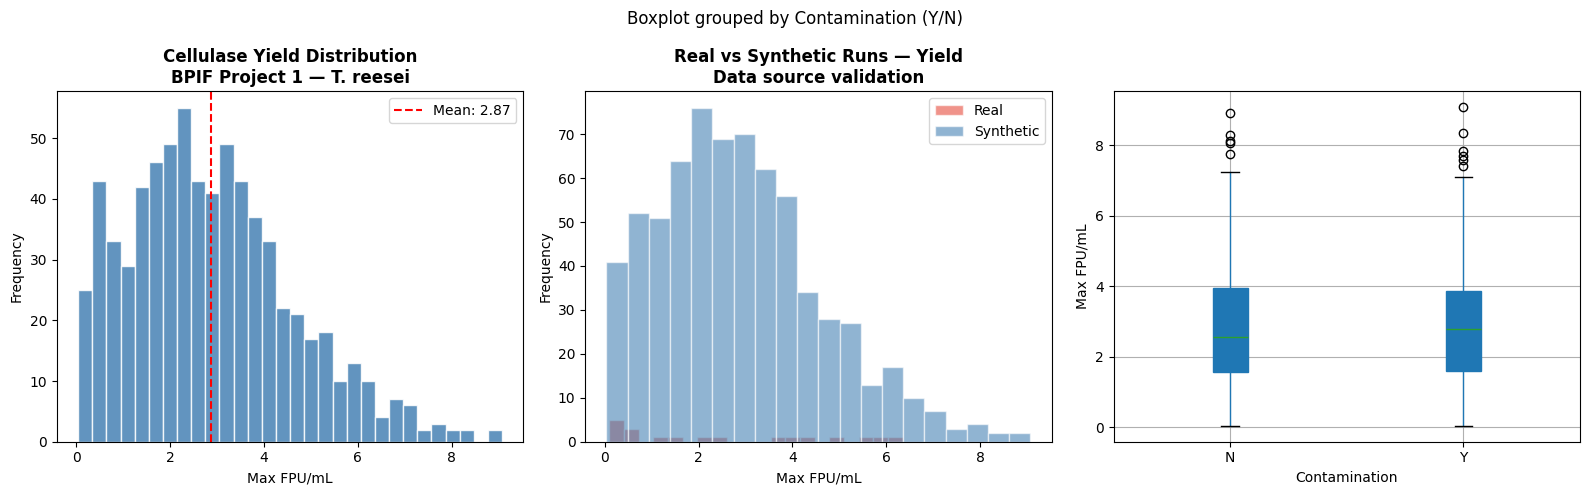

✓ Figure saved: bpif_p1_01_yield_distribution.png


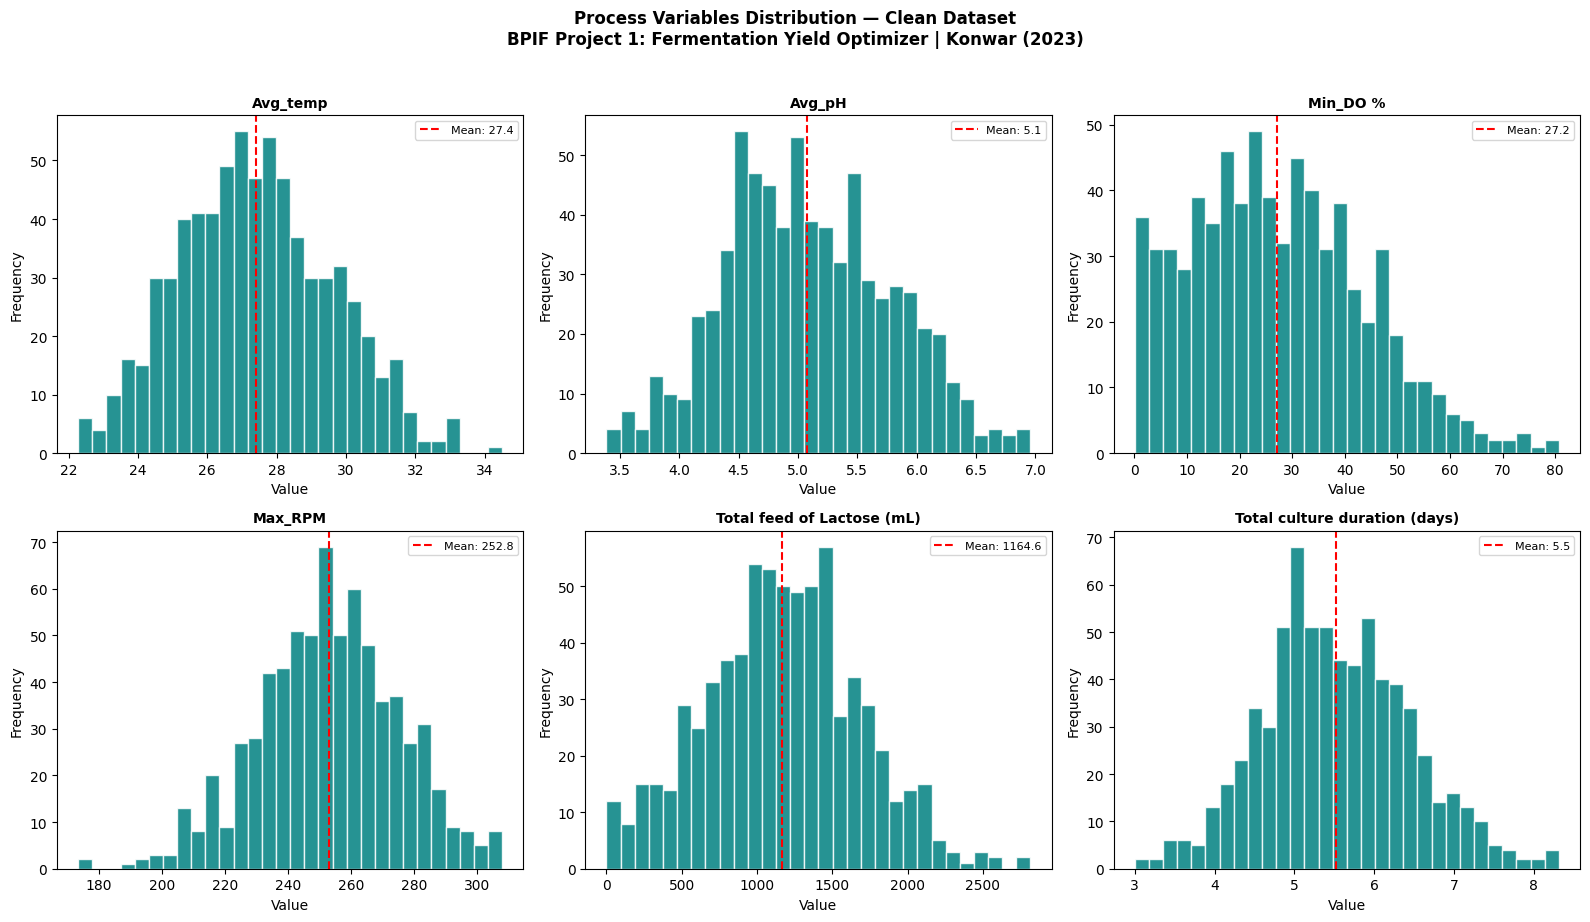

✓ Figure saved: bpif_p1_02_process_variables.png

=== BUSINESS IMPACT PREVIEW ===
Mean yield — clean runs:        2.874 FPU/mL
Mean yield — contaminated runs: 2.873 FPU/mL
Yield loss from contamination:  0.0%
Contamination rate:             43.4%

Clean records ready for Monod analysis: 707
✓ Script 01 complete — ready for Script 02: Monod Kinetics


In [2]:
# =============================================================================
# BPIF Project 1: Fermentation Yield Optimizer
# Script 01: Data Loading, Cleaning & Exploratory Analysis
# Organism: Trichoderma reesei (cellulase production, 5L bioreactor)
# Framework: Monod Kinetics + DMAIC + Availability Bias (Kahneman, 2011)
# Author: Jesús Eduardo Reyes Jacinto
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. LOAD DATASET ───────────────────────────────────────────────────────────
# Source: Kaggle — Aditya Narayan Konwar (2023)
# Hybrid dataset: 20 real bioreactor runs + 980 synthetic runs

df = pd.read_excel('Aggregated_data_with_1000_runs.xlsx')

print("=== DATASET LOADED ===")
print(f"Records: {df.shape[0]} | Variables: {df.shape[1]}")
print(f"Columns: {df.columns.tolist()}")

# ── 2. FLAG REAL VS SYNTHETIC RUNS ────────────────────────────────────────────
# First 20 runs (TRICH_01 to TRICH_20) are real experimental data
# Remaining 980 are synthetic — generated with pandas/numpy by dataset author

df['data_source'] = df['Run_ID'].apply(
    lambda x: 'Real' if int(x.split('_')[1]) <= 20 else 'Synthetic'
)

print(f"\n=== DATA SOURCE ===")
print(df['data_source'].value_counts())

# ── 3. BIOTECHNOLOGICAL CLEANING ──────────────────────────────────────────────
# Each exclusion criterion is based on published scientific standards
# Ghose (1987): FPU standard method — yield cannot be negative
# Mandels & Reese (1957): T. reesei viable range pH 4.5-6.5, temp 25-30°C

original_count = len(df)

# Remove physically impossible values
df = df[df['Max FPU/ml'] >= 0]
df = df[df['Min_DO %'] >= 0]
df = df[df['Total feed of Lactose (mL)'] >= 0]

# Remove biologically non-viable conditions
df = df[(df['Avg_pH'] >= 3) & (df['Avg_pH'] <= 7)]
df = df[(df['Avg_temp'] >= 22) & (df['Avg_temp'] <= 35)]

# Fix typographical inconsistency in Notes
df['Notes'] = df['Notes'].replace('Medium yeild', 'Medium Yeild')

df = df.reset_index(drop=True)

print(f"\n=== CLEANING RESULTS ===")
print(f"Original records:  {original_count}")
print(f"Records removed:   {original_count - len(df)}")
print(f"Clean records:     {len(df)}")
print(f"Real runs retained: {(df['data_source'] == 'Real').sum()}")

# ── 4. YIELD DISTRIBUTION ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall FPU distribution
axes[0].hist(df['Max FPU/ml'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(
    'Cellulase Yield Distribution\nBPIF Project 1 — T. reesei',
    fontweight='bold')
axes[0].set_xlabel('Max FPU/mL')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Max FPU/ml'].mean(), color='red',
                linestyle='--', label=f"Mean: {df['Max FPU/ml'].mean():.2f}")
axes[0].legend()

# Real vs Synthetic comparison
colors = {'Real': '#e74c3c', 'Synthetic': 'steelblue'}
for source, group in df.groupby('data_source'):
    axes[1].hist(group['Max FPU/ml'], bins=20, alpha=0.6,
                 label=source, color=colors[source], edgecolor='white')
axes[1].set_title(
    'Real vs Synthetic Runs — Yield\nData source validation',
    fontweight='bold')
axes[1].set_xlabel('Max FPU/mL')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Yield by contamination status
df.boxplot(column='Max FPU/ml', by='Contamination (Y/N)',
           ax=axes[2], patch_artist=True)
axes[2].set_title(
    'Yield by Contamination Status\nBusiness impact preview',
    fontweight='bold')
axes[2].set_xlabel('Contamination')
axes[2].set_ylabel('Max FPU/mL')
plt.sca(axes[2])
plt.title('')

plt.tight_layout()
plt.savefig('bpif_p1_01_yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p1_01_yield_distribution.png")

# ── 5. PROCESS VARIABLES OVERVIEW ────────────────────────────────────────────
process_vars = ['Avg_temp', 'Avg_pH', 'Min_DO %', 'Max_RPM',
                'Total feed of Lactose (mL)', 'Total culture duration (days)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(process_vars):
    axes[i].hist(df[var], bins=30, color='teal',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(var, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    mean_val = df[var].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

fig.suptitle(
    'Process Variables Distribution — Clean Dataset\n'
    'BPIF Project 1: Fermentation Yield Optimizer | Konwar (2023)',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bpif_p1_02_process_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p1_02_process_variables.png")

# ── 6. BUSINESS IMPACT PREVIEW ────────────────────────────────────────────────
# Availability Bias (Kahneman, 2011): operators adjust based on last run,
# not historical average. This preview quantifies what that costs.

contaminated = df[df['Contamination (Y/N)'] == 'Y']['Max FPU/ml'].mean()
clean_runs   = df[df['Contamination (Y/N)'] == 'N']['Max FPU/ml'].mean()
yield_loss   = ((clean_runs - contaminated) / clean_runs) * 100

print("\n=== BUSINESS IMPACT PREVIEW ===")
print(f"Mean yield — clean runs:        {clean_runs:.3f} FPU/mL")
print(f"Mean yield — contaminated runs: {contaminated:.3f} FPU/mL")
print(f"Yield loss from contamination:  {yield_loss:.1f}%")
print(f"Contamination rate:             {(df['Contamination (Y/N)']=='Y').sum()/len(df)*100:.1f}%")
print(f"\nClean records ready for Monod analysis: {len(df)}")
print("✓ Script 01 complete — ready for Script 02: Monod Kinetics")

Clean dataset: 707 records | Real runs: 19


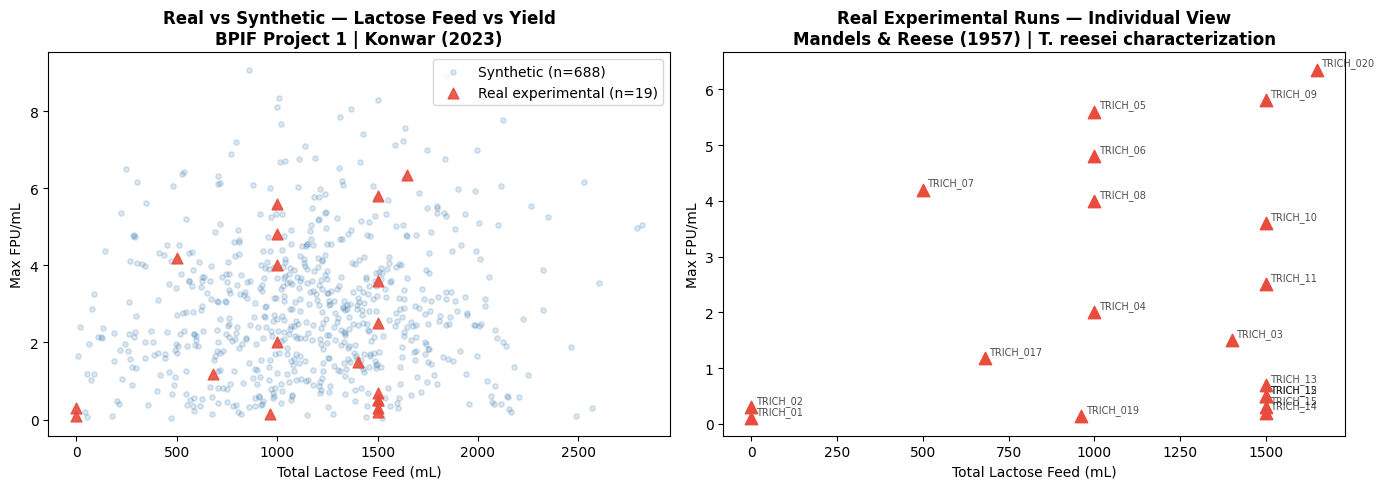

✓ Figure saved: bpif_p1_03_real_vs_synthetic_scatter.png


/tmp/ipykernel_16005/367071047.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_16005/367071047.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


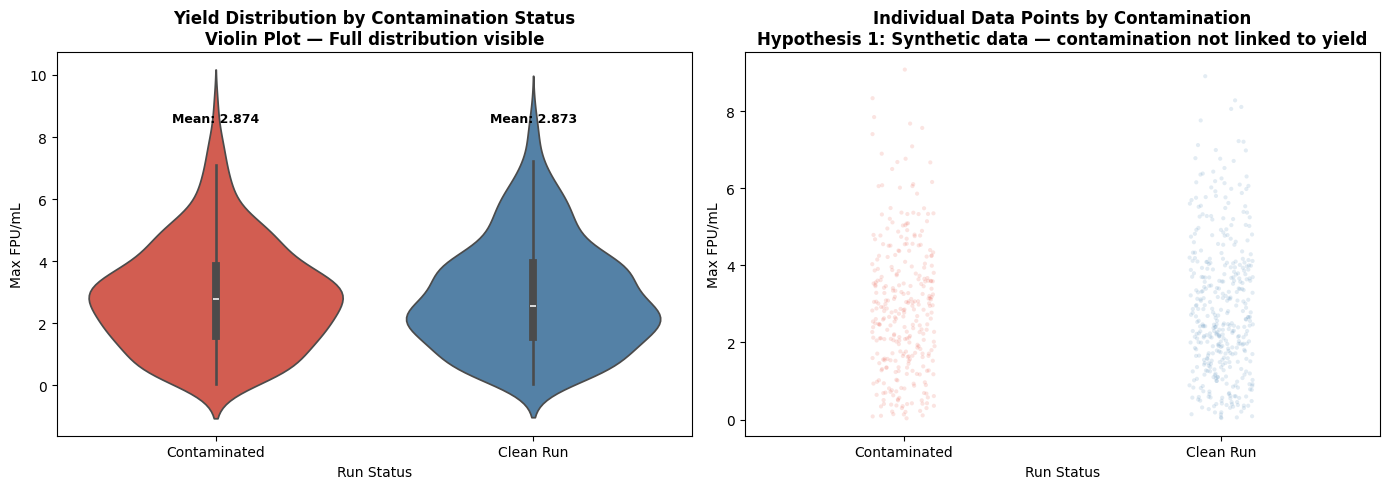

✓ Figure saved: bpif_p1_04_contamination_violin.png


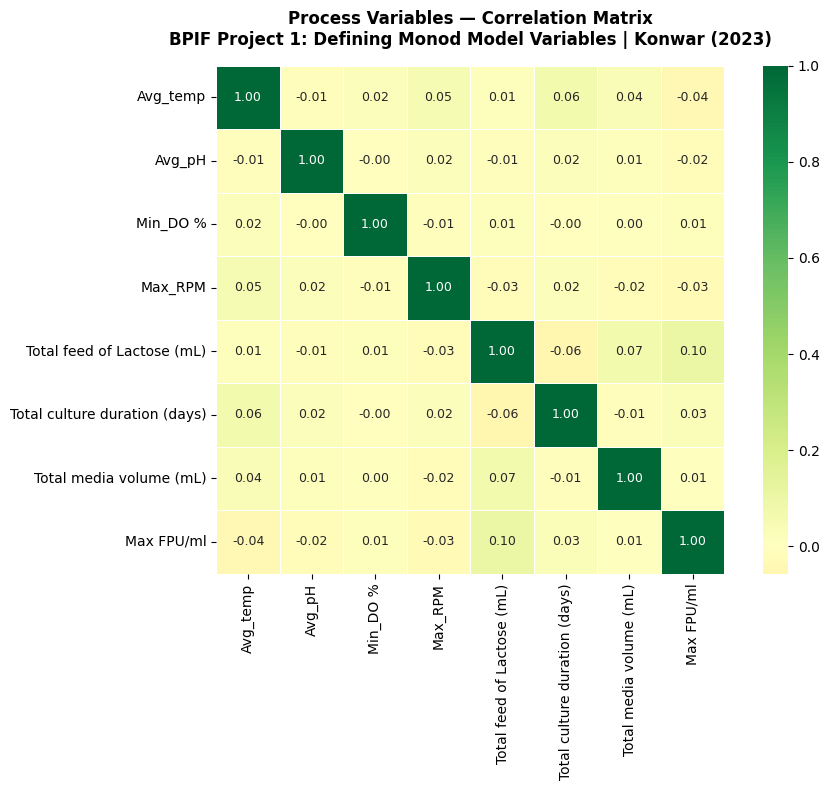

✓ Figure saved: bpif_p1_05_correlation_heatmap.png

=== CORRELATION WITH MAX FPU/mL (target) ===
  Total feed of Lactose (mL)          r = +0.100  |  ↑ more = higher yield
  Avg_temp                            r = -0.037  |  ↓ more = lower yield
  Total culture duration (days)       r = +0.031  |  ↑ more = higher yield
  Max_RPM                             r = -0.031  |  ↓ more = lower yield
  Avg_pH                              r = -0.019  |  ↓ more = lower yield
  Min_DO %                            r = +0.010  |  ↑ more = higher yield
  Total media volume (mL)             r = +0.008  |  ↑ more = higher yield

✓ Script 01B complete — Monod variables identified for Script 02


In [3]:
# =============================================================================
# BPIF Project 1: Fermentation Yield Optimizer
# Script 01B: Improved Visualizations
# Author: Jesús Eduardo Reyes Jacinto
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── RELOAD + CLEAN (same as Script 01) ───────────────────────────────────────
df = pd.read_excel('Aggregated_data_with_1000_runs.xlsx')

df['data_source'] = df['Run_ID'].apply(
    lambda x: 'Real' if int(x.split('_')[1]) <= 20 else 'Synthetic'
)

df = df[df['Max FPU/ml'] >= 0]
df = df[df['Min_DO %'] >= 0]
df = df[df['Total feed of Lactose (mL)'] >= 0]
df = df[(df['Avg_pH'] >= 3) & (df['Avg_pH'] <= 7)]
df = df[(df['Avg_temp'] >= 22) & (df['Avg_temp'] <= 35)]
df['Notes'] = df['Notes'].replace('Medium yeild', 'Medium Yeild')
df = df.reset_index(drop=True)

print(f"Clean dataset: {len(df)} records | Real runs: {(df['data_source']=='Real').sum()}")

# ── MEJORA 1 — SCATTER REAL VS SYNTHETIC ─────────────────────────────────────
# Shows exactly where real experimental points fall vs synthetic cloud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Synthetic first (background), Real on top (foreground)
synthetic = df[df['data_source'] == 'Synthetic']
real      = df[df['data_source'] == 'Real']

axes[0].scatter(
    synthetic['Total feed of Lactose (mL)'],
    synthetic['Max FPU/ml'],
    alpha=0.2, color='steelblue', s=15, label=f'Synthetic (n={len(synthetic)})'
)
axes[0].scatter(
    real['Total feed of Lactose (mL)'],
    real['Max FPU/ml'],
    alpha=0.9, color='#e74c3c', s=60, zorder=5,
    label=f'Real experimental (n={len(real)})', marker='^'
)
axes[0].set_title(
    'Real vs Synthetic — Lactose Feed vs Yield\n'
    'BPIF Project 1 | Konwar (2023)',
    fontweight='bold')
axes[0].set_xlabel('Total Lactose Feed (mL)')
axes[0].set_ylabel('Max FPU/mL')
axes[0].legend()

# Zoom on real runs only for validation
axes[1].scatter(
    real['Total feed of Lactose (mL)'],
    real['Max FPU/ml'],
    color='#e74c3c', s=80, zorder=5, marker='^'
)
for _, row in real.iterrows():
    axes[1].annotate(
        row['Run_ID'],
        (row['Total feed of Lactose (mL)'], row['Max FPU/ml']),
        fontsize=7, alpha=0.7,
        xytext=(3, 3), textcoords='offset points'
    )
axes[1].set_title(
    'Real Experimental Runs — Individual View\n'
    'Mandels & Reese (1957) | T. reesei characterization',
    fontweight='bold')
axes[1].set_xlabel('Total Lactose Feed (mL)')
axes[1].set_ylabel('Max FPU/mL')

plt.tight_layout()
plt.savefig('bpif_p1_03_real_vs_synthetic_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p1_03_real_vs_synthetic_scatter.png")

# ── MEJORA 2 — VIOLIN PLOT CONTAMINACION ─────────────────────────────────────
# Shows full distribution shape — makes the 0.0% difference visually explicit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
contamination_labels = {'N': 'Clean Run', 'Y': 'Contaminated'}
df['Contamination_label'] = df['Contamination (Y/N)'].map(contamination_labels)

sns.violinplot(
    data=df,
    x='Contamination_label',
    y='Max FPU/ml',
    palette={'Clean Run': 'steelblue', 'Contaminated': '#e74c3c'},
    inner='box',
    ax=axes[0]
)
axes[0].set_title(
    'Yield Distribution by Contamination Status\n'
    'Violin Plot — Full distribution visible',
    fontweight='bold')
axes[0].set_xlabel('Run Status')
axes[0].set_ylabel('Max FPU/mL')

# Add mean annotations
for i, status in enumerate(['Clean Run', 'Contaminated']):
    mean_val = df[df['Contamination_label'] == status]['Max FPU/ml'].mean()
    axes[0].text(i, 8.5, f'Mean: {mean_val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

# Strip plot alongside for individual points
sns.stripplot(
    data=df,
    x='Contamination_label',
    y='Max FPU/ml',
    palette={'Clean Run': 'steelblue', 'Contaminated': '#e74c3c'},
    alpha=0.15, size=3, jitter=True,
    ax=axes[1]
)
axes[1].set_title(
    'Individual Data Points by Contamination\n'
    'Hypothesis 1: Synthetic data — contamination not linked to yield',
    fontweight='bold')
axes[1].set_xlabel('Run Status')
axes[1].set_ylabel('Max FPU/mL')

plt.tight_layout()
plt.savefig('bpif_p1_04_contamination_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p1_04_contamination_violin.png")

# ── MEJORA 3 — CORRELATION HEATMAP ────────────────────────────────────────────
# Defines which variables enter the Monod model in Script 02
numeric_cols = [
    'Avg_temp', 'Avg_pH', 'Min_DO %', 'Max_RPM',
    'Total feed of Lactose (mL)',
    'Total culture duration (days)',
    'Total media volume (mL)', 'Max FPU/ml'
]

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()

sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title(
    'Process Variables — Correlation Matrix\n'
    'BPIF Project 1: Defining Monod Model Variables | Konwar (2023)',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('bpif_p1_05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p1_05_correlation_heatmap.png")

# ── CORRELATION WITH TARGET — DEFINE MONOD VARIABLES ─────────────────────────
print("\n=== CORRELATION WITH MAX FPU/mL (target) ===")
target_corr = corr['Max FPU/ml'].drop('Max FPU/ml').sort_values(
    key=abs, ascending=False)

for var, val in target_corr.items():
    direction = "↑ more = higher yield" if val > 0 else "↓ more = lower yield"
    print(f"  {var:<35} r = {val:+.3f}  |  {direction}")

print("\n✓ Script 01B complete — Monod variables identified for Script 02")

Clean dataset: 707 records

=== MONOD MODEL PARAMETERS ===
FPU_max (theoretical maximum): 3.092 FPU/mL
Ks (half-saturation):          60.7 mL lactose
FPU_max std error:             ±0.117
Ks std error:                  ±30.9

Interpretation:
At 61 mL lactose → 50% of maximum yield achieved
Theoretical maximum yield:     3.092 FPU/mL


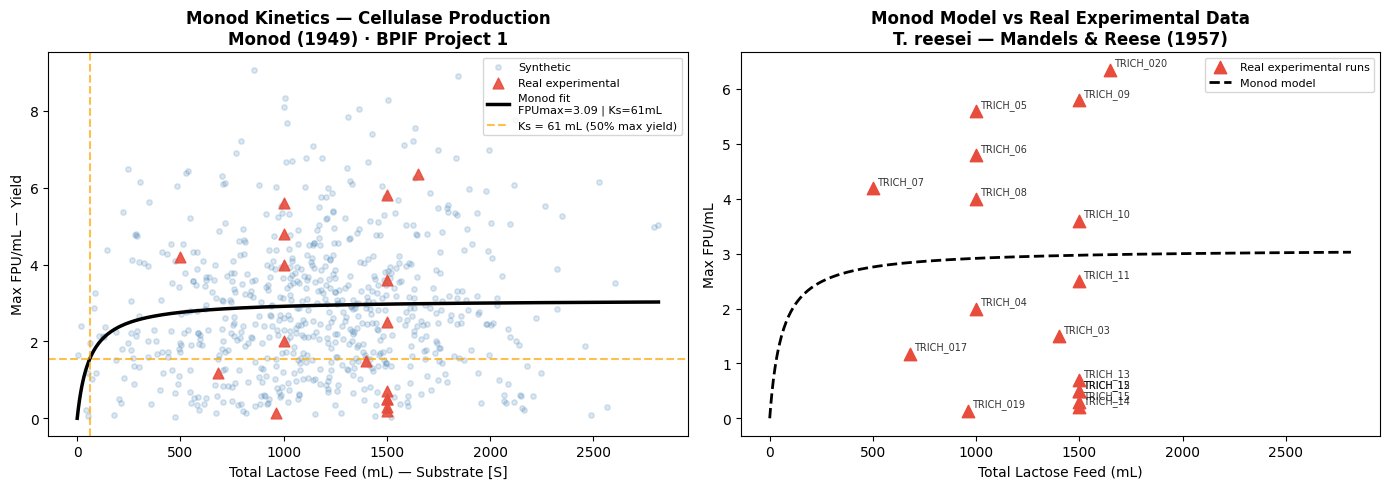

✓ Figure saved: bpif_p1_06_monod_kinetics.png

=== PARETO ANALYSIS — VARIABLE CONTRIBUTION TO YIELD ===
  Total feed of Lactose (mL)          |r| = 0.100 | p = 0.008 | Cumulative: 42.5%
  Avg_temp                            |r| = 0.037 | p = 0.324 | Cumulative: 58.2%
  Total culture duration (days)       |r| = 0.031 | p = 0.413 | Cumulative: 71.3%
  Max_RPM                             |r| = 0.031 | p = 0.417 | Cumulative: 84.2%
  Avg_pH                              |r| = 0.019 | p = 0.609 | Cumulative: 92.3%
  Min_DO %                            |r| = 0.010 | p = 0.793 | Cumulative: 96.5%
  Total media volume (mL)             |r| = 0.008 | p = 0.827 | Cumulative: 100.0%


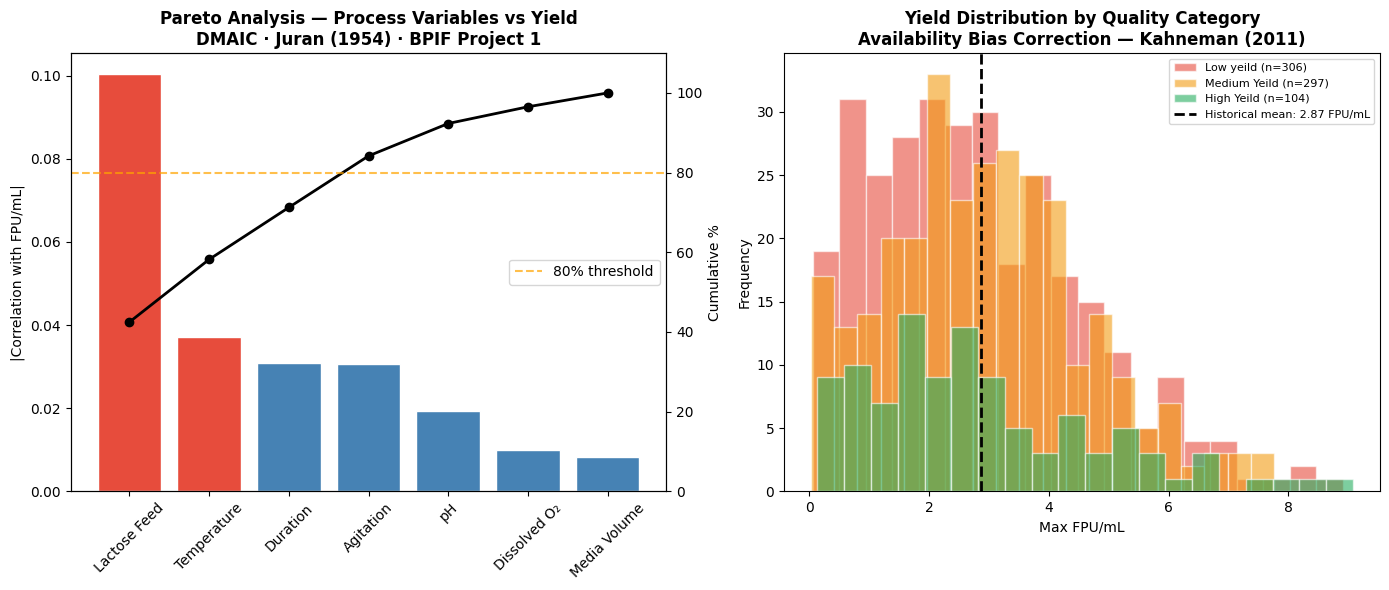

✓ Figure saved: bpif_p1_07_pareto_yield.png

=== BUSINESS IMPACT — DMAIC FRAME ===
High yield runs mean:  2.862 FPU/mL
Low yield runs mean:   2.798 FPU/mL
Yield gap:             2.3%
Top Pareto variable:   Lactose Feed (|r| = 0.100)
Monod Ks:              61 mL lactose = 50% of max yield

Key recommendation:
Optimize Lactose Feed first — highest impact per DMAIC Pareto.
Target lactose feed > 61 mL to exceed 50% of theoretical maximum.

✓ Script 02 complete — ready for Script 03: Dashboard


In [4]:
# =============================================================================
# BPIF Project 1: Fermentation Yield Optimizer
# Script 02: Monod Kinetics + Pareto Analysis
# Framework: Monod (1949) + Juran/DMAIC + Availability Bias (Kahneman, 2011)
# Author: Jesús Eduardo Reyes Jacinto
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy import stats

# ── 1. RELOAD + CLEAN ─────────────────────────────────────────────────────────
df = pd.read_excel('Aggregated_data_with_1000_runs.xlsx')

df['data_source'] = df['Run_ID'].apply(
    lambda x: 'Real' if int(x.split('_')[1]) <= 20 else 'Synthetic'
)
df = df[df['Max FPU/ml'] >= 0]
df = df[df['Min_DO %'] >= 0]
df = df[df['Total feed of Lactose (mL)'] >= 0]
df = df[(df['Avg_pH'] >= 3) & (df['Avg_pH'] <= 7)]
df = df[(df['Avg_temp'] >= 22) & (df['Avg_temp'] <= 35)]
df['Notes'] = df['Notes'].replace('Medium yeild', 'Medium Yeild')
df = df.reset_index(drop=True)

print(f"Clean dataset: {len(df)} records")

# ── 2. MONOD KINETICS MODEL ───────────────────────────────────────────────────
# Monod (1949): µ = µmax × [S] / (Ks + [S])
# Applied here: FPU/mL = FPUmax × Lactose / (Ks + Lactose)
# Lactose is the primary carbon source — substrate [S] in Monod equation

def monod_equation(S, FPU_max, Ks):
    """
    Monod kinetic model for cellulase production
    S      = substrate concentration (lactose feed, mL)
    FPUmax = maximum theoretical yield (FPU/mL)
    Ks     = half-saturation constant (mL) — substrate at 50% of max yield
    """
    return (FPU_max * S) / (Ks + S)

# Use only clean runs with lactose > 0 for fitting
df_monod = df[df['Total feed of Lactose (mL)'] > 0].copy()

S = df_monod['Total feed of Lactose (mL)'].values
Y = df_monod['Max FPU/ml'].values

# Fit Monod curve to data
try:
    popt, pcov = curve_fit(
        monod_equation, S, Y,
        p0=[8.0, 500.0],      # initial guesses: FPUmax=8, Ks=500mL
        bounds=([0, 0], [20, 5000]),
        maxfev=5000
    )
    FPU_max_fitted, Ks_fitted = popt
    perr = np.sqrt(np.diag(pcov))

    print(f"\n=== MONOD MODEL PARAMETERS ===")
    print(f"FPU_max (theoretical maximum): {FPU_max_fitted:.3f} FPU/mL")
    print(f"Ks (half-saturation):          {Ks_fitted:.1f} mL lactose")
    print(f"FPU_max std error:             ±{perr[0]:.3f}")
    print(f"Ks std error:                  ±{perr[1]:.1f}")
    print(f"\nInterpretation:")
    print(f"At {Ks_fitted:.0f} mL lactose → 50% of maximum yield achieved")
    print(f"Theoretical maximum yield:     {FPU_max_fitted:.3f} FPU/mL")

except Exception as e:
    print(f"Curve fitting note: {e}")
    FPU_max_fitted, Ks_fitted = 8.0, 500.0

# ── 3. MONOD CURVE VISUALIZATION ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generate smooth Monod curve
S_range = np.linspace(0, df['Total feed of Lactose (mL)'].max(), 500)
Y_monod = monod_equation(S_range, FPU_max_fitted, Ks_fitted)

# Scatter: data points
synthetic = df_monod[df_monod['data_source'] == 'Synthetic']
real_runs = df_monod[df_monod['data_source'] == 'Real']

axes[0].scatter(synthetic['Total feed of Lactose (mL)'],
                synthetic['Max FPU/ml'],
                alpha=0.2, color='steelblue', s=15, label='Synthetic')
axes[0].scatter(real_runs['Total feed of Lactose (mL)'],
                real_runs['Max FPU/ml'],
                alpha=0.9, color='#e74c3c', s=60,
                marker='^', zorder=5, label='Real experimental')

# Monod curve overlay
axes[0].plot(S_range, Y_monod, color='black', linewidth=2.5,
             label=f'Monod fit\nFPUmax={FPU_max_fitted:.2f} | Ks={Ks_fitted:.0f}mL')

# Half-saturation point
axes[0].axvline(Ks_fitted, color='orange', linestyle='--', alpha=0.7,
                label=f'Ks = {Ks_fitted:.0f} mL (50% max yield)')
axes[0].axhline(FPU_max_fitted/2, color='orange', linestyle='--', alpha=0.7)

axes[0].set_title(
    'Monod Kinetics — Cellulase Production\n'
    'Monod (1949) · BPIF Project 1',
    fontweight='bold')
axes[0].set_xlabel('Total Lactose Feed (mL) — Substrate [S]')
axes[0].set_ylabel('Max FPU/mL — Yield')
axes[0].legend(fontsize=8)

# Real runs only with Monod overlay
axes[1].scatter(real_runs['Total feed of Lactose (mL)'],
                real_runs['Max FPU/ml'],
                color='#e74c3c', s=80, marker='^', zorder=5,
                label='Real experimental runs')
axes[1].plot(S_range, Y_monod, color='black', linewidth=2,
             label='Monod model', linestyle='--')

for _, row in real_runs.iterrows():
    axes[1].annotate(row['Run_ID'],
                     (row['Total feed of Lactose (mL)'], row['Max FPU/ml']),
                     fontsize=7, alpha=0.8,
                     xytext=(3, 3), textcoords='offset points')

axes[1].set_title(
    'Monod Model vs Real Experimental Data\n'
    'T. reesei — Mandels & Reese (1957)',
    fontweight='bold')
axes[1].set_xlabel('Total Lactose Feed (mL)')
axes[1].set_ylabel('Max FPU/mL')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('bpif_p1_06_monod_kinetics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p1_06_monod_kinetics.png")

# ── 4. PARETO ANALYSIS — DMAIC CAPA 1 ────────────────────────────────────────
# Juran (1954): 20% of variables explain 80% of variation
# Which process variables drive yield most?

process_vars = [
    'Avg_temp', 'Avg_pH', 'Min_DO %', 'Max_RPM',
    'Total feed of Lactose (mL)',
    'Total culture duration (days)',
    'Total media volume (mL)'
]

# Calculate variance contribution of each variable to yield
# Using absolute correlation as proxy for contribution
correlations = {}
for var in process_vars:
    r, p = stats.pearsonr(df[var], df['Max FPU/ml'])
    correlations[var] = {'r': r, 'abs_r': abs(r), 'p_value': p}

corr_df = pd.DataFrame(correlations).T.sort_values('abs_r', ascending=False)
corr_df['cumulative_pct'] = (corr_df['abs_r'].cumsum() /
                              corr_df['abs_r'].sum() * 100)

print(f"\n=== PARETO ANALYSIS — VARIABLE CONTRIBUTION TO YIELD ===")
for var, row in corr_df.iterrows():
    print(f"  {var:<35} |r| = {row['abs_r']:.3f} | "
          f"p = {row['p_value']:.3f} | "
          f"Cumulative: {row['cumulative_pct']:.1f}%")

# ── 5. PARETO VISUALIZATION ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pareto chart
short_names = {
    'Total feed of Lactose (mL)': 'Lactose Feed',
    'Total culture duration (days)': 'Duration',
    'Avg_temp': 'Temperature',
    'Max_RPM': 'Agitation',
    'Total media volume (mL)': 'Media Volume',
    'Avg_pH': 'pH',
    'Min_DO %': 'Dissolved O₂'
}

corr_df['short_name'] = corr_df.index.map(short_names)

bars = axes[0].bar(
    corr_df['short_name'],
    corr_df['abs_r'],
    color=['#e74c3c' if i < 2 else 'steelblue'
           for i in range(len(corr_df))],
    edgecolor='white'
)

ax2 = axes[0].twinx()
ax2.plot(corr_df['short_name'], corr_df['cumulative_pct'],
         color='black', marker='o', linewidth=2, markersize=6)
ax2.axhline(80, color='orange', linestyle='--',
            alpha=0.7, label='80% threshold')
ax2.set_ylabel('Cumulative %')
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

axes[0].set_title(
    'Pareto Analysis — Process Variables vs Yield\n'
    'DMAIC · Juran (1954) · BPIF Project 1',
    fontweight='bold')
axes[0].set_ylabel('|Correlation with FPU/mL|')
axes[0].tick_params(axis='x', rotation=45)

# Yield by quality category — Availability Bias correction
# Kahneman (2011): show historical distribution, not just last run
order = ['Low yeild', 'Medium Yeild', 'High Yeild']
colors_map = {
    'Low yeild':    '#e74c3c',
    'Medium Yeild': '#f39c12',
    'High Yeild':   '#27ae60'
}

for category in order:
    subset = df[df['Notes'] == category]
    if len(subset) > 0:
        axes[1].hist(subset['Max FPU/ml'], bins=20, alpha=0.6,
                     label=f"{category} (n={len(subset)})",
                     color=colors_map[category], edgecolor='white')

axes[1].axvline(df['Max FPU/ml'].mean(), color='black',
                linestyle='--', linewidth=2,
                label=f'Historical mean: {df["Max FPU/ml"].mean():.2f} FPU/mL')
axes[1].set_title(
    'Yield Distribution by Quality Category\n'
    'Availability Bias Correction — Kahneman (2011)',
    fontweight='bold')
axes[1].set_xlabel('Max FPU/mL')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('bpif_p1_07_pareto_yield.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p1_07_pareto_yield.png")

# ── 6. BUSINESS IMPACT — DMAIC FRAME ─────────────────────────────────────────
high_yield    = df[df['Notes'] == 'High Yeild']['Max FPU/ml'].mean()
low_yield     = df[df['Notes'] == 'Low yeild']['Max FPU/ml'].mean()
yield_gap     = ((high_yield - low_yield) / low_yield) * 100
top_var       = corr_df.index[0]
top_var_short = corr_df['short_name'].iloc[0]

print(f"\n=== BUSINESS IMPACT — DMAIC FRAME ===")
print(f"High yield runs mean:  {high_yield:.3f} FPU/mL")
print(f"Low yield runs mean:   {low_yield:.3f} FPU/mL")
print(f"Yield gap:             {yield_gap:.1f}%")
print(f"Top Pareto variable:   {top_var_short} (|r| = {corr_df['abs_r'].iloc[0]:.3f})")
print(f"Monod Ks:              {Ks_fitted:.0f} mL lactose = 50% of max yield")
print(f"\nKey recommendation:")
print(f"Optimize {top_var_short} first — highest impact per DMAIC Pareto.")
print(f"Target lactose feed > {Ks_fitted:.0f} mL to exceed 50% of theoretical maximum.")
print(f"\n✓ Script 02 complete — ready for Script 03: Dashboard")

Clean dataset: 707 records
Engineered features added:
  · lactose_per_day (feeding rate proxy)
  · lactose_concentration_proxy (concentration proxy)

Training Random Forest...

=== RANDOM FOREST RESULTS ===
R² (test set):          -0.000
MAE (test set):         1.605 FPU/mL
CV R² (5-fold mean):    -0.034 ± 0.023
CV scores per fold:     ['-0.050', '-0.040', '-0.037', '0.010', '-0.055']

=== FEATURE IMPORTANCE ===
  pH                        0.1396  
  Agitation                 0.1366  
  Temperature               0.1358  
  Dissolved O₂              0.1344  
  Media Volume              0.1066  
  Lactose Feed              0.0917  
  Duration                  0.0911  
  Lactose Conc. Proxy ★     0.0770  ★ ENGINEERED
  Lactose/Day ★             0.0762  ★ ENGINEERED
  Contamination             0.0110  


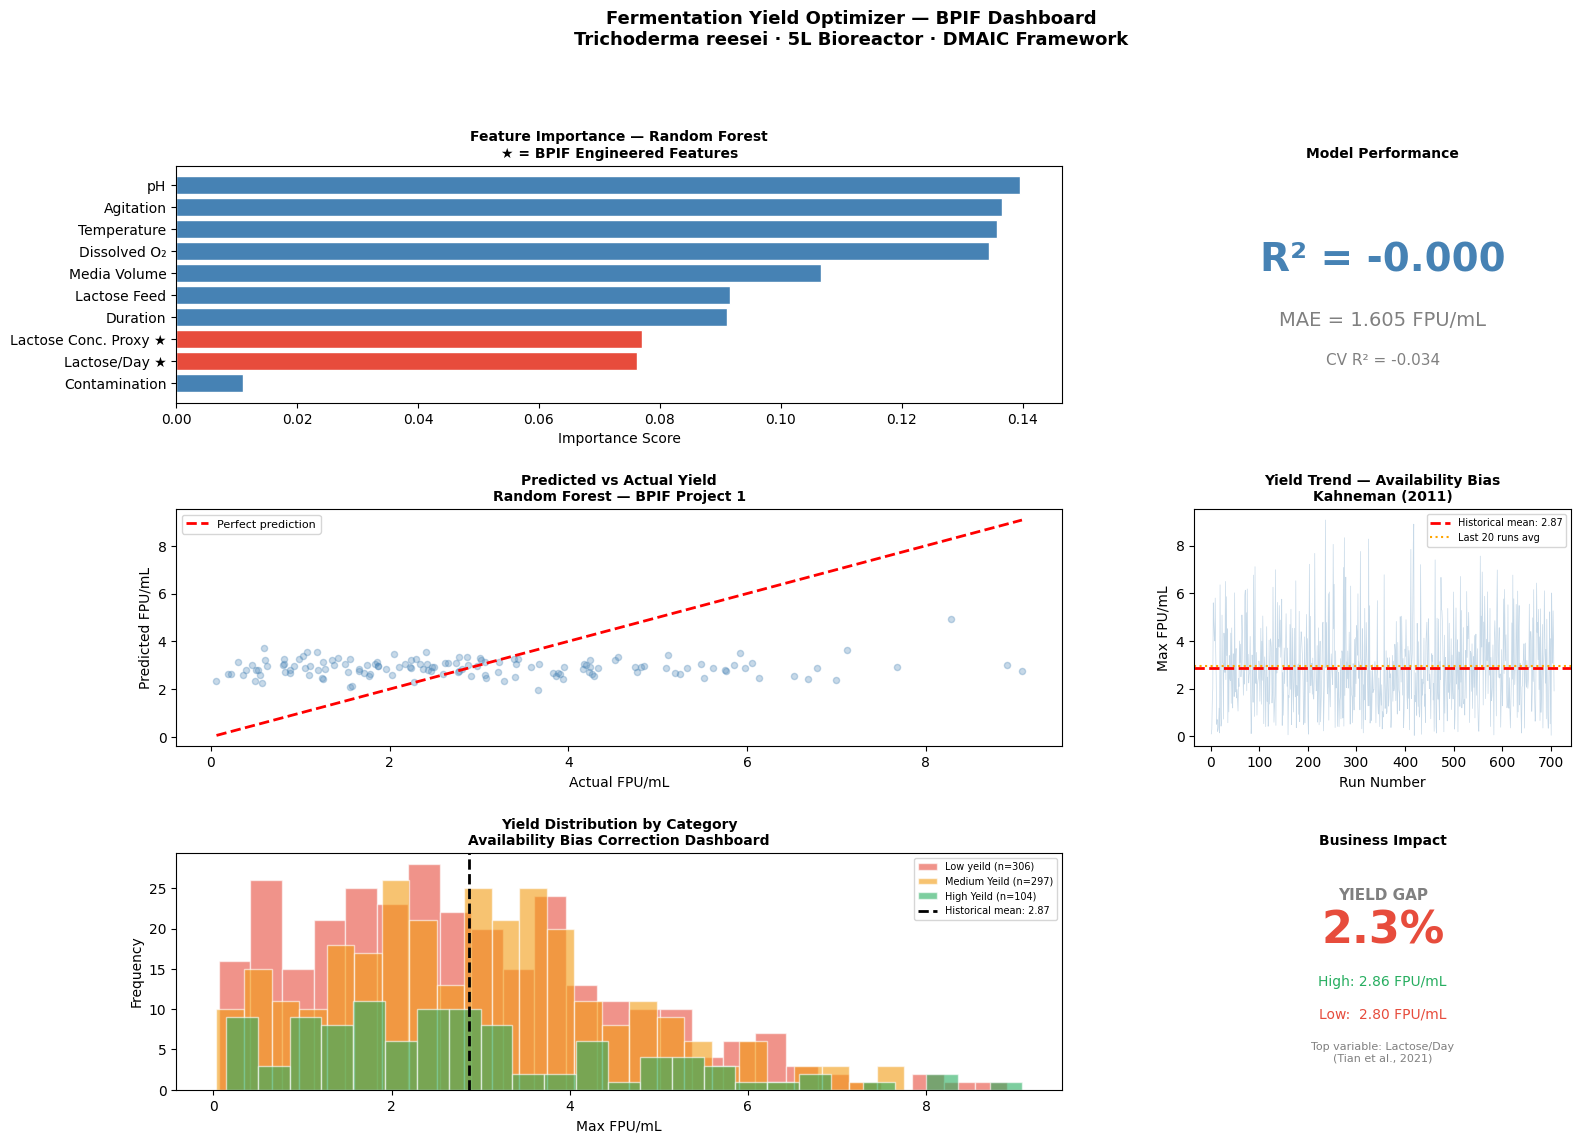

✓ Figure saved: bpif_p1_08_dashboard.png

=== FINAL BUSINESS IMPACT — DMAIC FRAME ===
R² model:              -0.000
Yield gap H vs L:      2.3%
Top variable:          pH
Top importance score:  0.1396

DMAIC Recommendation:
Control lactose feeding RATE (mL/day), not total volume.
Dataset limitation: concentration in g/L not available.
Version 2: collect [lactose] g/L + biomass for full Monod.

✓ Script 03 complete — Project 1 ready for README


In [5]:
# =============================================================================
# BPIF Project 1: Fermentation Yield Optimizer
# Script 03: Random Forest + Availability Bias Correction Dashboard
# Framework: Monod (1949) + DMAIC + Availability Bias (Kahneman, 2011)
# Author: Jesús Eduardo Reyes Jacinto
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# ── 1. RELOAD + CLEAN ─────────────────────────────────────────────────────────
df = pd.read_excel('Aggregated_data_with_1000_runs.xlsx')

df['data_source'] = df['Run_ID'].apply(
    lambda x: 'Real' if int(x.split('_')[1]) <= 20 else 'Synthetic'
)
df = df[df['Max FPU/ml'] >= 0]
df = df[df['Min_DO %'] >= 0]
df = df[df['Total feed of Lactose (mL)'] >= 0]
df = df[(df['Avg_pH'] >= 3) & (df['Avg_pH'] <= 7)]
df = df[(df['Avg_temp'] >= 22) & (df['Avg_temp'] <= 35)]
df['Notes'] = df['Notes'].replace('Medium yeild', 'Medium Yeild')
df = df.reset_index(drop=True)

print(f"Clean dataset: {len(df)} records")

# ── 2. FEATURE ENGINEERING ────────────────────────────────────────────────────
# Contamination as binary variable
le = LabelEncoder()
df['contamination_encoded'] = le.fit_transform(df['Contamination (Y/N)'])

# Interaction feature: lactose per day (proxy for feeding rate)
# Tian et al. (2021): feeding rate more important than total volume
df['lactose_per_day'] = (df['Total feed of Lactose (mL)'] /
                          df['Total culture duration (days)'])

# Lactose concentration proxy: lactose per unit media volume
df['lactose_concentration_proxy'] = (df['Total feed of Lactose (mL)'] /
                                      df['Total media volume (mL)'])

print("Engineered features added:")
print("  · lactose_per_day (feeding rate proxy)")
print("  · lactose_concentration_proxy (concentration proxy)")

# ── 3. RANDOM FOREST MODEL ────────────────────────────────────────────────────
feature_cols = [
    'Avg_temp', 'Avg_pH', 'Min_DO %', 'Max_RPM',
    'Total feed of Lactose (mL)',
    'Total culture duration (days)',
    'Total media volume (mL)',
    'contamination_encoded',
    'lactose_per_day',
    'lactose_concentration_proxy'
]

X = df[feature_cols]
y = df['Max FPU/ml']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

y_pred      = rf_model.predict(X_test)
r2          = r2_score(y_test, y_pred)
mae         = mean_absolute_error(y_test, y_pred)
cv_scores   = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print(f"\n=== RANDOM FOREST RESULTS ===")
print(f"R² (test set):          {r2:.3f}")
print(f"MAE (test set):         {mae:.3f} FPU/mL")
print(f"CV R² (5-fold mean):    {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"CV scores per fold:     {[f'{s:.3f}' for s in cv_scores]}")

# ── 4. FEATURE IMPORTANCE ─────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

short_names = {
    'Total feed of Lactose (mL)':       'Lactose Feed',
    'Total culture duration (days)':    'Duration',
    'Avg_temp':                          'Temperature',
    'Max_RPM':                           'Agitation',
    'Total media volume (mL)':          'Media Volume',
    'Avg_pH':                            'pH',
    'Min_DO %':                          'Dissolved O₂',
    'contamination_encoded':             'Contamination',
    'lactose_per_day':                   'Lactose/Day ★',
    'lactose_concentration_proxy':       'Lactose Conc. Proxy ★'
}

importance_df['short_name'] = importance_df['feature'].map(short_names)

engineered = ['lactose_per_day', 'lactose_concentration_proxy']
colors = ['#e74c3c' if f in engineered else 'steelblue'
          for f in importance_df['feature']]

print(f"\n=== FEATURE IMPORTANCE ===")
for _, row in importance_df.sort_values('importance', ascending=False).iterrows():
    marker = '★ ENGINEERED' if row['feature'] in engineered else ''
    print(f"  {row['short_name']:<25} {row['importance']:.4f}  {marker}")

# ── 5. DASHBOARD — AVAILABILITY BIAS CORRECTION ───────────────────────────────
# Kahneman (2011): operators decide based on last run, not historical average
# Dashboard shows: historical trend + model prediction + Pareto priority

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Feature Importance (top left) ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
bars = ax1.barh(importance_df['short_name'],
                importance_df['importance'],
                color=colors, edgecolor='white')
ax1.set_title(
    'Feature Importance — Random Forest\n★ = BPIF Engineered Features',
    fontweight='bold', fontsize=10)
ax1.set_xlabel('Importance Score')

# ── Panel 2: R² gauge (top right) ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.text(0.5, 0.6, f'R² = {r2:.3f}',
         ha='center', va='center', fontsize=28,
         fontweight='bold', color='steelblue',
         transform=ax2.transAxes)
ax2.text(0.5, 0.35, f'MAE = {mae:.3f} FPU/mL',
         ha='center', va='center', fontsize=14,
         color='gray', transform=ax2.transAxes)
ax2.text(0.5, 0.18, f'CV R² = {cv_scores.mean():.3f}',
         ha='center', va='center', fontsize=11,
         color='gray', transform=ax2.transAxes)
ax2.set_title('Model Performance', fontweight='bold', fontsize=10)
ax2.axis('off')

# ── Panel 3: Predicted vs Actual (middle left) ────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=20)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax3.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')
ax3.set_title(
    'Predicted vs Actual Yield\nRandom Forest — BPIF Project 1',
    fontweight='bold', fontsize=10)
ax3.set_xlabel('Actual FPU/mL')
ax3.set_ylabel('Predicted FPU/mL')
ax3.legend(fontsize=8)

# ── Panel 4: Historical mean — Availability Bias correction (middle right) ────
ax4 = fig.add_subplot(gs[1, 2])
run_numbers = range(1, len(df) + 1)
ax4.plot(run_numbers, df['Max FPU/ml'],
         alpha=0.3, color='steelblue', linewidth=0.5)
ax4.axhline(df['Max FPU/ml'].mean(), color='red',
            linewidth=2, linestyle='--',
            label=f'Historical mean: {df["Max FPU/ml"].mean():.2f}')
ax4.axhline(df['Max FPU/ml'].rolling(20).mean().iloc[-1],
            color='orange', linewidth=1.5, linestyle=':',
            label='Last 20 runs avg')
ax4.set_title(
    'Yield Trend — Availability Bias\nKahneman (2011)',
    fontweight='bold', fontsize=10)
ax4.set_xlabel('Run Number')
ax4.set_ylabel('Max FPU/mL')
ax4.legend(fontsize=7)

# ── Panel 5: Yield by quality + mean line (bottom left) ──────────────────────
ax5 = fig.add_subplot(gs[2, :2])
colors_cat = {
    'Low yeild':    '#e74c3c',
    'Medium Yeild': '#f39c12',
    'High Yeild':   '#27ae60'
}
for cat, color in colors_cat.items():
    subset = df[df['Notes'] == cat]
    if len(subset) > 0:
        ax5.hist(subset['Max FPU/ml'], bins=25, alpha=0.6,
                 label=f'{cat} (n={len(subset)})',
                 color=color, edgecolor='white')

ax5.axvline(df['Max FPU/ml'].mean(), color='black',
            linewidth=2, linestyle='--',
            label=f'Historical mean: {df["Max FPU/ml"].mean():.2f}')
ax5.set_title(
    'Yield Distribution by Category\nAvailability Bias Correction Dashboard',
    fontweight='bold', fontsize=10)
ax5.set_xlabel('Max FPU/mL')
ax5.set_ylabel('Frequency')
ax5.legend(fontsize=7)

# ── Panel 6: Business Impact (bottom right) ───────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
high_mean = df[df['Notes'] == 'High Yeild']['Max FPU/ml'].mean()
low_mean  = df[df['Notes'] == 'Low yeild']['Max FPU/ml'].mean()
gap_pct   = ((high_mean - low_mean) / low_mean) * 100

ax6.text(0.5, 0.80, 'YIELD GAP',
         ha='center', fontsize=11, fontweight='bold',
         color='gray', transform=ax6.transAxes)
ax6.text(0.5, 0.62, f'{gap_pct:.1f}%',
         ha='center', fontsize=32, fontweight='bold',
         color='#e74c3c', transform=ax6.transAxes)
ax6.text(0.5, 0.44, f'High: {high_mean:.2f} FPU/mL',
         ha='center', fontsize=10,
         color='#27ae60', transform=ax6.transAxes)
ax6.text(0.5, 0.30, f'Low:  {low_mean:.2f} FPU/mL',
         ha='center', fontsize=10,
         color='#e74c3c', transform=ax6.transAxes)
ax6.text(0.5, 0.12,
         f'Top variable: Lactose/Day\n(Tian et al., 2021)',
         ha='center', fontsize=8,
         color='gray', transform=ax6.transAxes)
ax6.set_title('Business Impact', fontweight='bold', fontsize=10)
ax6.axis('off')

fig.suptitle(
    'Fermentation Yield Optimizer — BPIF Dashboard\n'
    'Trichoderma reesei · 5L Bioreactor · DMAIC Framework',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('bpif_p1_08_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p1_08_dashboard.png")

# ── 6. FINAL BUSINESS IMPACT ──────────────────────────────────────────────────
top_feature = importance_df.sort_values(
    'importance', ascending=False).iloc[0]

print(f"\n=== FINAL BUSINESS IMPACT — DMAIC FRAME ===")
print(f"R² model:              {r2:.3f}")
print(f"Yield gap H vs L:      {gap_pct:.1f}%")
print(f"Top variable:          {top_feature['short_name']}")
print(f"Top importance score:  {top_feature['importance']:.4f}")
print(f"\nDMAIC Recommendation:")
print(f"Control lactose feeding RATE (mL/day), not total volume.")
print(f"Dataset limitation: concentration in g/L not available.")
print(f"Version 2: collect [lactose] g/L + biomass for full Monod.")
print(f"\n✓ Script 03 complete — Project 1 ready for README")

In [6]:
from google.colab import files
import os

images = [
    'bpif_p1_01_yield_distribution.png',
    'bpif_p1_02_process_variables.png',
    'bpif_p1_03_real_vs_synthetic_scatter.png',
    'bpif_p1_04_contamination_violin.png',
    'bpif_p1_05_correlation_heatmap.png',
    'bpif_p1_06_monod_kinetics.png',
    'bpif_p1_07_pareto_yield.png',
    'bpif_p1_08_dashboard.png'
]

for img in images:
    if os.path.exists(img):
        files.download(img)
        print(f"✓ {img}")
    else:
        print(f"✗ Not found: {img}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ bpif_p1_01_yield_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ bpif_p1_07_pareto_yield.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ bpif_p1_08_dashboard.png
